#  Brain Tumor MRI Classification
## Project 2 – Representation Learning

---

### Notebook Overview
This notebook covers **Task 1: Data Preparation** 
which includes:
- Environment setup & imports
- Dataset loading & inspection
- Class distribution analysis
- Image resizing & preprocessing
- Data augmentation
- DataLoader creation
- Sample visualisation

**Dataset:** Brain Tumor MRI Dataset (Kaggle) — 7,023 images, 4 classes  
**Framework:** PyTorch  
**Author:** *Shilpa Golla*, *DiviTeja Dimmiti*  
**Date:** March 2026

---
##  Step 1: Install & Import Libraries

In [1]:
# ── Install missing packages 
!pip install torch torchvision matplotlib seaborn scikit-learn Pillow tqdm -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"Device          : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

PyTorch version : 2.5.1+cu121
CUDA available  : True
Device          : NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
import sys
!{sys.executable} -m pip install tqdm Pillow torch torchvision matplotlib seaborn scikit-learn -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


---
## Step 2: Fix Random Seeds (Reproducibility)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f"All random seeds fixed to {SEED}")

All random seeds fixed to 42


---
## Step 3: Dataset Path Configuration

In [6]:
DATA_ROOT = Path(r"C:\Users\golla\Downloads\Brain Tumor Classification from MRI Images\archive (2)")   

TRAIN_DIR = DATA_ROOT / 'Training'
TEST_DIR  = DATA_ROOT / 'Testing'

# ── Class configuration ────────────────────────────────────────────────────────
CLASS_NAMES  = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_LABELS = {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
NUM_CLASSES  = 4

# ── Image & training hyperparameters ──────────────────────────────────────────
IMG_SIZE   = 224          # resize target (height × width)
BATCH_SIZE = 32
NUM_WORKERS = 2           # set 0 on Windows if you get errors

# ── Verify directories exist ───────────────────────────────────────────────────
for d in [TRAIN_DIR, TEST_DIR]:
    assert d.exists(), f"Directory not found: {d}"
    print(f"Found: {d}")

Found: C:\Users\golla\Downloads\Brain Tumor Classification from MRI Images\archive (2)\Training
Found: C:\Users\golla\Downloads\Brain Tumor Classification from MRI Images\archive (2)\Testing


---
## Step 4: Dataset Inspection

In [9]:
# ── Count images per class in each split ──────────────────────────────────────
def count_images(split_dir: Path) -> dict:
    """Return {class_name: image_count} for a dataset split directory."""
    counts = {}
    for cls in CLASS_NAMES:
        cls_path = split_dir / cls
        if cls_path.exists():
            images = list(cls_path.glob('*.jpg')) + \
                     list(cls_path.glob('*.jpeg')) + \
                     list(cls_path.glob('*.png'))
            counts[cls] = len(images)
        else:
            counts[cls] = 0
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())

print("=" * 55)
print(f"{'Class':<15} {'Train':>8} {'Test':>8} {'Train %':>10}")
print("-" * 55)
for cls in CLASS_NAMES:
    pct = train_counts[cls] / total_train * 100
    print(f"{cls:<15} {train_counts[cls]:>8} {test_counts[cls]:>8} {pct:>9.1f}%")
print("-" * 55)
print(f"{'TOTAL':<15} {total_train:>8} {total_test:>8}")
print("=" * 55)

Class              Train     Test    Train %
-------------------------------------------------------
glioma              1400      400      25.0%
meningioma          1400      400      25.0%
notumor             1400      400      25.0%
pituitary           1400      400      25.0%
-------------------------------------------------------
TOTAL               5600     1600


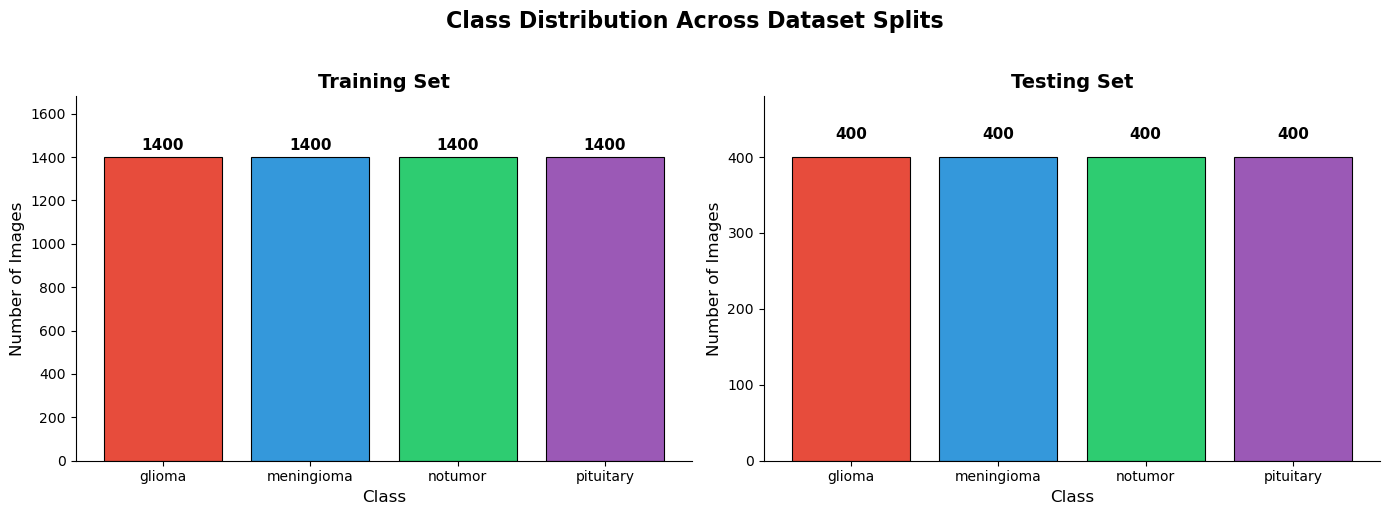

Saved: class_distribution.png


In [10]:
# ── Visualise class distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ['Training Set', 'Testing Set']):
    bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('Number of Images', fontsize=12)
    ax.set_ylim(0, max(counts.values()) * 1.2)
    # Add count labels on top of bars
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Class Distribution Across Dataset Splits', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

---
## Step 5: Inspect Raw Image Properties

In [11]:
def get_image_stats(split_dir: Path, sample_per_class: int = 100) -> list:
    """Collect (width, height, mode) for a random sample of images."""
    stats = []
    for cls in CLASS_NAMES:
        cls_path = split_dir / cls
        all_imgs = (list(cls_path.glob('*.jpg')) +
                    list(cls_path.glob('*.jpeg')) +
                    list(cls_path.glob('*.png')))
        sample = random.sample(all_imgs, min(sample_per_class, len(all_imgs)))
        for p in sample:
            img = Image.open(p)
            stats.append({'class': cls, 'width': img.width,
                          'height': img.height, 'mode': img.mode})
    return stats

print("Sampling images for size analysis...")
img_stats = get_image_stats(TRAIN_DIR)

widths  = [s['width']  for s in img_stats]
heights = [s['height'] for s in img_stats]
modes   = Counter(s['mode'] for s in img_stats)

print(f"\n Image Size Statistics (sample of {len(img_stats)} images):")
print(f"  Width  — min: {min(widths):>4}, max: {max(widths):>4}, mean: {np.mean(widths):>6.1f}")
print(f"  Height — min: {min(heights):>4}, max: {max(heights):>4}, mean: {np.mean(heights):>6.1f}")
print(f"\n Colour Modes: {dict(modes)}")
print(f"\n→ All images will be resized to {IMG_SIZE}×{IMG_SIZE} and converted to RGB.")

Sampling images for size analysis...

 Image Size Statistics (sample of 400 images):
  Width  — min:  150, max: 1338, mean:  462.2
  Height — min:  168, max: 1304, mean:  466.3

 Colour Modes: {'L': 177, 'RGB': 222, 'P': 1}

→ All images will be resized to 224×224 and converted to RGB.


---
## Step 6: Define Transforms (Preprocessing + Augmentation)

In [13]:
# ── ImageNet statistics (used for pretrained models) ──────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ──────────────────────────────────────────────────────────────────────────────
# TRAIN transforms  →  augmentation + normalisation
# ──────────────────────────────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),          # resize to 224×224
    transforms.Grayscale(num_output_channels=3),      # ensure 3-channel RGB
    transforms.RandomHorizontalFlip(p=0.5),           # random horizontal mirror
    transforms.RandomVerticalFlip(p=0.2),             # rare vertical mirror
    transforms.RandomRotation(degrees=15),            # rotate ±15°
    transforms.ColorJitter(
        brightness=0.3,                               # brightness ±30%
        contrast=0.3,                                 # contrast  ±30%
        saturation=0.1),                              # slight saturation jitter
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),                         # shift up to 10%
        scale=(0.9, 1.1)),                            # zoom ±10%
    transforms.ToTensor(),                            # PIL → [0,1] tensor
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD) # normalise
])

# ──────────────────────────────────────────────────────────────────────────────
# TEST transforms  →  only resize + normalise (NO augmentation)
# ──────────────────────────────────────────────────────────────────────────────
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("Transform pipelines defined.")
print("\n Train pipeline:")
for i, t in enumerate(train_transforms.transforms):
    print(f"   {i+1}. {t}")
print("\n Test pipeline:")
for i, t in enumerate(test_transforms.transforms):
    print(f"   {i+1}. {t}")

Transform pipelines defined.

 Train pipeline:
   1. Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
   2. Grayscale(num_output_channels=3)
   3. RandomHorizontalFlip(p=0.5)
   4. RandomVerticalFlip(p=0.2)
   5. RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
   6. ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.9, 1.1), hue=None)
   7. RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1), scale=(0.9, 1.1))
   8. ToTensor()
   9. Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

 Test pipeline:
   1. Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
   2. Grayscale(num_output_channels=3)
   3. ToTensor()
   4. Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


---
## Step 7: Create Datasets & DataLoaders

In [15]:
# ── Load datasets using ImageFolder ───────────────────────────────────────────
train_dataset = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_transforms)
test_dataset  = datasets.ImageFolder(root=str(TEST_DIR),  transform=test_transforms)

print(f"Training images : {len(train_dataset)}")
print(f"Testing  images : {len(test_dataset)}")
print(f"\n Class → Index mapping : {train_dataset.class_to_idx}")

Training images : 5600
Testing  images : 1600

 Class → Index mapping : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [16]:
# ── Handle class imbalance with WeightedRandomSampler ─────────────────────────
# Count samples per class
class_counts = np.array([train_counts[cls] for cls in train_dataset.classes])
class_weights = 1.0 / class_counts           # inverse frequency weights

# Assign weight to every individual sample
sample_weights = np.array([class_weights[label] for _, label in train_dataset.samples])
sample_weights = torch.from_numpy(sample_weights).float()

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("WeightedRandomSampler created to handle class imbalance.")
print(f"   Class weights: { {cls: f'{w:.4f}' for cls, w in zip(CLASS_NAMES, class_weights)} }")

WeightedRandomSampler created to handle class imbalance.
   Class weights: {'glioma': '0.0007', 'meningioma': '0.0007', 'notumor': '0.0007', 'pituitary': '0.0007'}


In [17]:
# ── Build DataLoaders ──────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,              # balanced sampling
    num_workers=NUM_WORKERS,
    pin_memory=True               # faster GPU transfer
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,                # keep order for evaluation
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train DataLoader: {len(train_loader)} batches × {BATCH_SIZE} images")
print(f"Test  DataLoader: {len(test_loader)}  batches × {BATCH_SIZE} images")

# ── Verify a single batch ──────────────────────────────────────────────────────
images, labels = next(iter(train_loader))
print(f"\n Batch check:")
print(f"   Image tensor shape : {images.shape}  (B × C × H × W)")
print(f"   Label tensor shape : {labels.shape}")
print(f"   Pixel value range  : [{images.min():.3f}, {images.max():.3f}]")

Train DataLoader: 175 batches × 32 images
Test  DataLoader: 50  batches × 32 images

 Batch check:
   Image tensor shape : torch.Size([32, 3, 224, 224])  (B × C × H × W)
   Label tensor shape : torch.Size([32])
   Pixel value range  : [-2.118, 2.640]


---
## Step 8: Visualise Sample Images Per Class

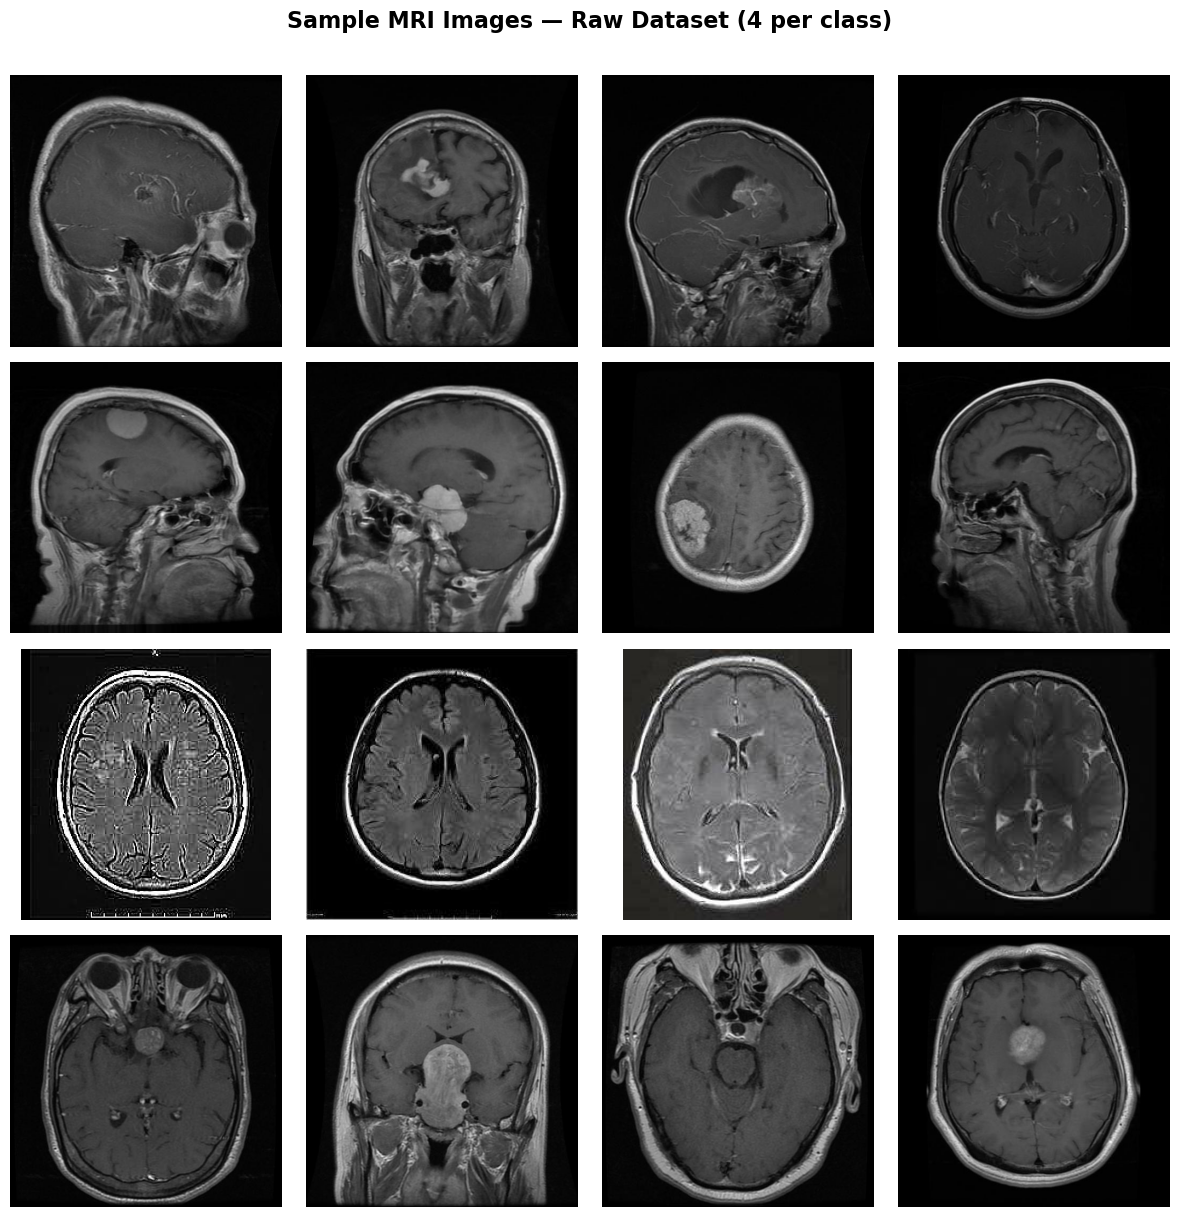

Saved: raw_samples.png


In [18]:
# ── Show raw (un-augmented) sample images from each class ─────────────────────
def show_raw_samples(split_dir: Path, n_per_class: int = 4):
    """Display n raw images per class in a grid."""
    fig, axes = plt.subplots(NUM_CLASSES, n_per_class,
                              figsize=(n_per_class * 3, NUM_CLASSES * 3))
    colors_map = dict(zip(CLASS_NAMES, colors))

    for row, cls in enumerate(CLASS_NAMES):
        cls_path = split_dir / cls
        imgs = list(cls_path.glob('*.jpg')) + list(cls_path.glob('*.jpeg'))
        sample = random.sample(imgs, min(n_per_class, len(imgs)))

        for col, img_path in enumerate(sample):
            img = Image.open(img_path).convert('RGB')
            ax  = axes[row][col]
            ax.imshow(img, cmap='gray')
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(cls.upper(), fontsize=12,
                              fontweight='bold', rotation=90,
                              color=colors_map[cls], labelpad=10)
                ax.yaxis.set_label_position('left')
                ax.set_yticks([])
                ax.spines['left'].set_color(colors_map[cls])
                ax.spines['left'].set_linewidth(3)

    fig.suptitle('Sample MRI Images — Raw Dataset (4 per class)',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('raw_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: raw_samples.png")

show_raw_samples(TRAIN_DIR)

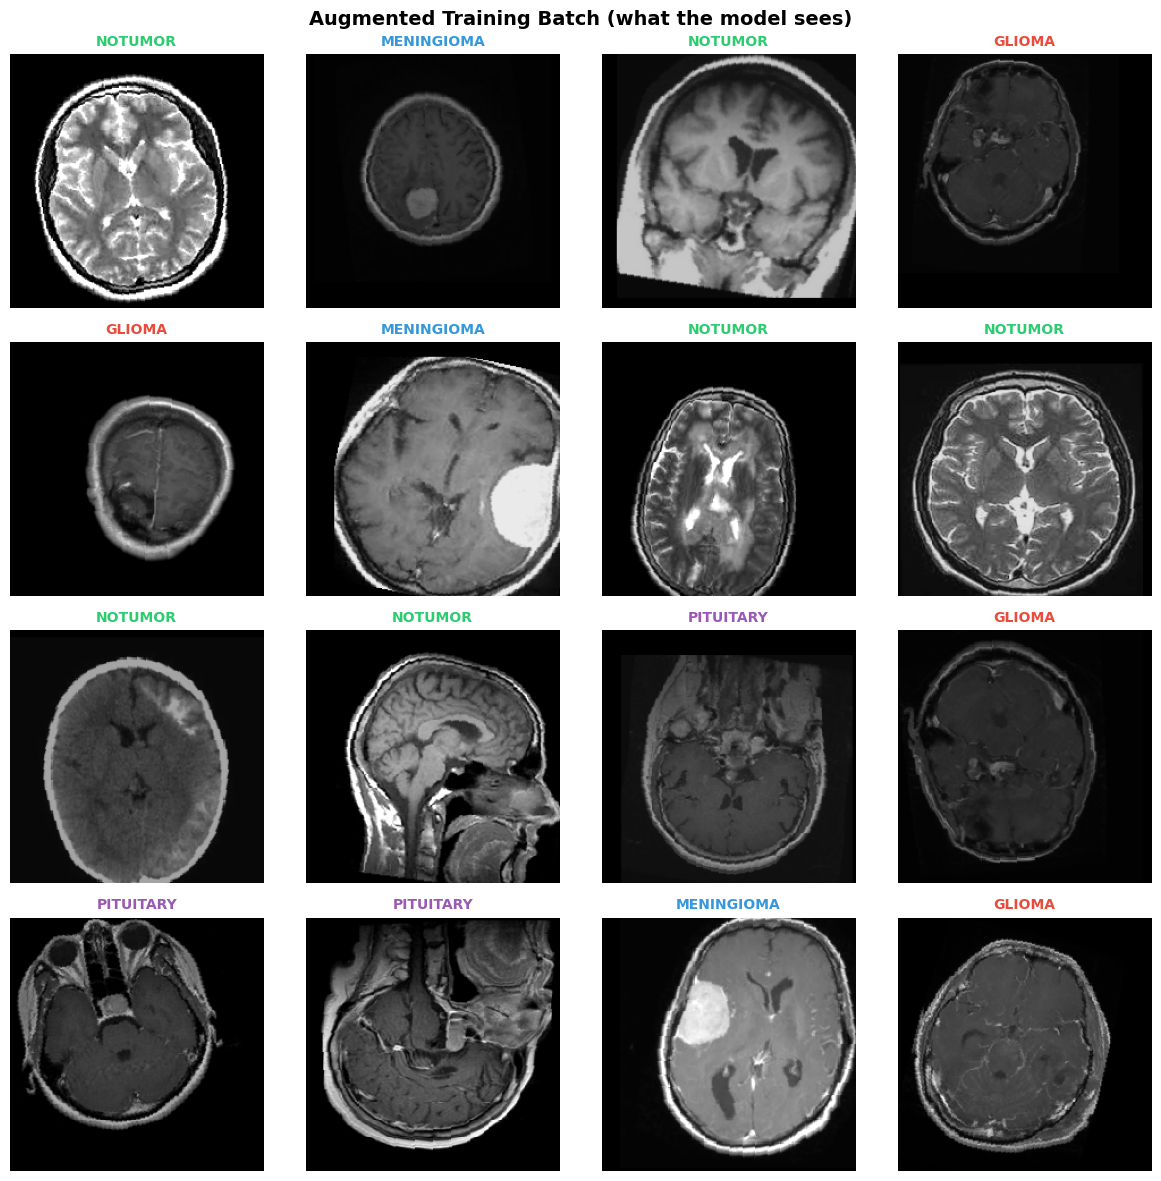

Saved: augmented_samples.png


In [19]:
# ── Show augmented samples (what the model actually sees) ─────────────────────
def denormalize(tensor):
    """Reverse ImageNet normalisation for display purposes."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

def show_augmented_batch(loader, n_images: int = 16):
    """Display a grid of augmented training images."""
    imgs, lbls = next(iter(loader))
    imgs = imgs[:n_images]
    lbls = lbls[:n_images]

    cols = 4
    rows = n_images // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

    for idx, (img, lbl) in enumerate(zip(imgs, lbls)):
        ax  = axes[idx // cols][idx % cols]
        npimg = denormalize(img).permute(1, 2, 0).numpy()
        ax.imshow(npimg)
        ax.set_title(CLASS_NAMES[lbl.item()].upper(),
                     fontsize=10, fontweight='bold',
                     color=colors[lbl.item()])
        ax.axis('off')

    fig.suptitle('Augmented Training Batch (what the model sees)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: augmented_samples.png")

show_augmented_batch(train_loader)

---
## Step 9: Compute Dataset Statistics (Mean & Std)

In [22]:
# ── Compute actual dataset mean & std 
# This cell computes the true per-channel statistics of your training set.
# We use a loader without normalisation for this purpose.

stats_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

stats_dataset = datasets.ImageFolder(root=str(TRAIN_DIR), transform=stats_transform)
stats_loader  = DataLoader(stats_dataset, batch_size=64,
                           shuffle=False, num_workers=NUM_WORKERS)

mean = torch.zeros(3)
std  = torch.zeros(3)
n_samples = 0

print("Computing dataset statistics...")
for imgs, _ in tqdm(stats_loader):
    b = imgs.size(0)
    imgs = imgs.view(b, 3, -1)          # B × C × (H*W)
    mean += imgs.mean(2).sum(0)
    std  += imgs.std(2).sum(0)
    n_samples += b

mean /= n_samples
std  /= n_samples

print(f"\n Dataset Statistics:")
print(f"   Mean : {mean.tolist()}")
print(f"   Std  : {std.tolist()}")
print(f"\n Using ImageNet values for transfer learning compatibility:")
print(f"   Mean : {IMAGENET_MEAN}")
print(f"   Std  : {IMAGENET_STD}")

Computing dataset statistics...


100%|██████████████████████████████████████████████████████████████████████████████████| 88/88 [01:06<00:00,  1.33it/s]


 Dataset Statistics:
   Mean : [0.18398892879486084, 0.18398892879486084, 0.18398892879486084]
   Std  : [0.17929095029830933, 0.17929095029830933, 0.17929095029830933]

 Using ImageNet values for transfer learning compatibility:
   Mean : [0.485, 0.456, 0.406]
   Std  : [0.229, 0.224, 0.225]


---
## Step 10: Summary & Save Artefacts

In [23]:
print("=" * 60)
print(" DATA PREPARATION — SUMMARY")
print("=" * 60)
print(f"  Dataset          : Brain Tumor MRI (Kaggle)")
print(f"  Classes          : {CLASS_NAMES}")
print(f"  Training images  : {len(train_dataset)}")
print(f"  Testing images   : {len(test_dataset)}")
print(f"  Image size       : {IMG_SIZE} × {IMG_SIZE} px")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Train batches    : {len(train_loader)}")
print(f"  Test  batches    : {len(test_loader)}")
print(f"  Augmentation     : Flip, Rotate, ColorJitter, Affine")
print(f"  Class balance    : WeightedRandomSampler applied")
print(f"  Normalisation    : ImageNet Mean/Std")
print(f"  Random seed      : {SEED}")
print("=" * 60)
print("\n Data preparation complete! Ready for model training.")
print("   → Open train.ipynb for MLP, CNN, and Transfer Learning.")

 DATA PREPARATION — SUMMARY
  Dataset          : Brain Tumor MRI (Kaggle)
  Classes          : ['glioma', 'meningioma', 'notumor', 'pituitary']
  Training images  : 5600
  Testing images   : 1600
  Image size       : 224 × 224 px
  Batch size       : 32
  Train batches    : 175
  Test  batches    : 50
  Augmentation     : Flip, Rotate, ColorJitter, Affine
  Class balance    : WeightedRandomSampler applied
  Normalisation    : ImageNet Mean/Std
  Random seed      : 42

 Data preparation complete! Ready for model training.
   → Open train.ipynb for MLP, CNN, and Transfer Learning.


In [24]:
import json

config = {
    'seed'           : SEED,
    'img_size'       : IMG_SIZE,
    'batch_size'     : BATCH_SIZE,
    'num_classes'    : NUM_CLASSES,
    'class_names'    : CLASS_NAMES,
    'class_to_idx'   : train_dataset.class_to_idx,
    'train_size'     : len(train_dataset),
    'test_size'      : len(test_dataset),
    'imagenet_mean'  : IMAGENET_MEAN,
    'imagenet_std'   : IMAGENET_STD,
    'train_counts'   : train_counts,
    'test_counts'    : test_counts
}

with open('config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("Saved: config.json (shared across all notebooks)")

Saved: config.json (shared across all notebooks)
